In [1]:
import dataclasses
import json

import h5py
import numpy as np
import matplotlib.pyplot as plt

from lib.plots import set_axis

In [89]:
@dataclasses.dataclass
class CohesinHistory:
    birth_frame: int
    trajectory: list[tuple[int, int]] | np.ndarray


config_id = 7
instance_id = 1
phase_key = "production"

with h5py.File(f"_outputs/output-{config_id}-{instance_id}.h5", "r") as store:
    config_used = json.loads(store["metadata/config"][()])
    config_source = json.loads(store["metadata/config_source"][()])

    phase_store = store["phases"][phase_key]

    loop_key = None
    if "loop_capture" in config_source:
        loop_key = "captures"
    if "loop_extrusion" in config_source:
        loop_key = "extruders"

    cohesin_histories = {}
    for frame_index, step_key in enumerate(phase_store[".steps"]):
        sample = phase_store[step_key]

        for cohesin_id, (loaded_site, captured_site) in zip(
            sample[loop_key]["ids"],
            sample[loop_key]["sites"],
        ):
            if cohesin_id not in cohesin_histories:
                cohesin_histories[cohesin_id] = CohesinHistory(
                    birth_frame=frame_index,
                    trajectory=[],
                )
            cohesin_histories[cohesin_id].trajectory.append(
                (loaded_site, captured_site)
            )

for history in cohesin_histories.values():
    history.trajectory = np.array(history.trajectory)
cohesin_ids = list(cohesin_histories.keys())

data_label = f"config-{config_id} instance {instance_id} / {phase_key}"

In [90]:
phases = {
    phase["name"]: phase for phase in config_used["sampling"]["phases"]
}

sampling_config = config_used["sampling"]
phase_config = {**sampling_config, **phases[phase_key]}
del phase_config["phases"]

frame_duration = phase_config["timestep"] * phase_config["sampling_interval"]
phase_duration = phase_config["timestep"] * phase_config["steps"]

chain_length = config_used["chains"][0]["length"]

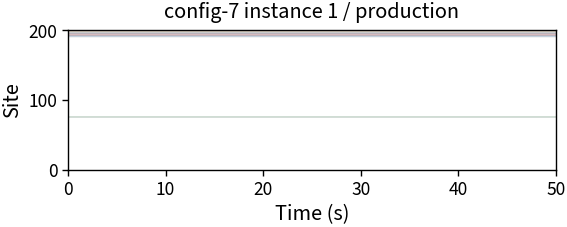

In [91]:
fig, ax = plt.subplots(figsize=(2.9, 1.2))

for history in cohesin_histories.values():
    x = (history.birth_frame + np.arange(len(history.trajectory))) * frame_duration
    y1 = history.trajectory[:, 0]
    y2 = history.trajectory[:, 1]
    ax.fill_between(x, y1, y2, edgecolor="k", lw=0.2, alpha=0.2)

ax.set_xlim(0, phase_duration)
ax.set_ylim(0, chain_length)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Site")
ax.set_title(data_label)

pass